# LAB4 : Facial Detection Systems

# Part 2: Facial Detection using Deep Learning

Face detection is a fundamental problem in computer vision and is widely used in applications such as security systems, human–computer interaction, smart surveillance, and biometric authentication. In this assignment, students will implement a deep learning–based facial detection system using a Convolutional Neural Network (CNN).

The goal of this is to understand how neural networks can be trained to classify images as **face** or **non-face**. Students will explore the dataset, train a classifier, evaluate its performance, and visualize the predictions.

students will also briefly observe how machine learning systems may behave differently across different datasets or demographic groups. Understanding such behavior is important for designing responsible and ethical AI systems.

---

## Learning Objectives

After completing this asssignemnt, students should be able to:

- Understand the basic workflow of a computer vision pipeline for facial detection.
- Implement and train a CNN-based binary image classifier. CLO2
- Evaluate the performance of a trained model on test data.
- Visualize and interpret the predictions of a deep learning model.

---

In [2]:
# Import Tensorflow 2.0
import tensorflow as tf

import IPython
import functools
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# # Download and import the MIT 6.S191 package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2.1 Datasets

We'll be using three datasets in this lab. In order to train our facial detection models, we'll need a dataset of positive examples (i.e., of faces) and a dataset of negative examples (i.e., of things that are not faces). We'll use these data to train our models to classify images as either faces or not faces. Finally, we'll need a test dataset of face images.

1.   **Positive training data**: [CelebA Dataset](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html). A large-scale (over 200K images) of celebrity faces.   
2.   **Negative training data**: [ImageNet](http://www.image-net.org/). Many images across many different categories. We'll take negative examples from a variety of non-human categories.
[Fitzpatrick Scale](https://en.wikipedia.org/wiki/Fitzpatrick_scale) skin type classification system, with each image labeled as "Lighter'' or "Darker''.

Let's begin by importing these datasets. We've written a class that does a bit of data pre-processing to import the training data in a usable format.

In [3]:
# Get the training data: both images from CelebA and ImageNet
path_to_training_data = tf.keras.utils.get_file('train_face.h5', 'https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1')
# Instantiate a TrainingDatasetLoader using the downloaded dataset
loader = mdl.lab2.TrainingDatasetLoader(path_to_training_data)

Opening /root/.keras/datasets/train_face.h5
Loading data into memory...


We can look at the size of the training dataset and grab a batch of size 100:

In [4]:
number_of_training_examples = loader.get_train_size()
print(number_of_training_examples)

109914
(100, 64, 64, 3)
(100, 1)


Play around with displaying images to get a sense of what the training data actually looks like!

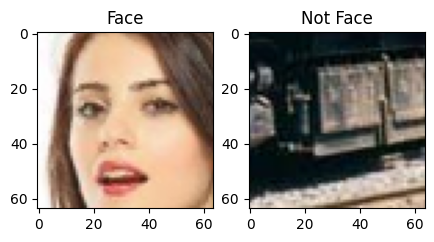

In [23]:
### Examining the CelebA training dataset ###

#@title Change the sliders to look at positive and negative training examples! { run: "auto" }

# Load a new batch of images every time the cell is run (e.g., when slider is changed)
(images, labels) = loader.get_batch(100)

face_images = images[np.where(labels==1)[0]]
not_face_images = images[np.where(labels==0)[0]]

idx_face = 15 #@param {type:"slider", min:0, max:50, step:1}
idx_not_face = 21 #@param {type:"slider", min:0, max:50, step:1}

# Ensure selected indices are within valid bounds
max_face_idx = len(face_images) - 1
if max_face_idx < 0: # Handle case where there are no face images in the batch
    idx_face = 0
elif idx_face > max_face_idx:
    idx_face = max_face_idx

max_not_face_idx = len(not_face_images) - 1
if max_not_face_idx < 0: # Handle case where there are no non-face images in the batch
    idx_not_face = 0
elif idx_not_face > max_not_face_idx:
    idx_not_face = max_not_face_idx

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
if len(face_images) > 0:
    plt.imshow(face_images[idx_face])
    plt.title("Face")
else:
    plt.title("No Face Images in Batch")
plt.grid(False)

plt.subplot(1, 2, 2)
if len(not_face_images) > 0:
    plt.imshow(not_face_images[idx_not_face])
    plt.title("Not Face")
else:
    plt.title("No Non-Face Images in Batch")
plt.grid(False)

## 2.2 CNN for facial detection

we'll define and train a CNN on the facial classification task, and evaluate its accuracy. The CNN model has a relatively standard architecture consisting of a series of convolutional layers with batch normalization followed by two fully connected layers to flatten the convolution output and generate a class prediction.

The classifier should contain the following layers:

| Layer | Type | Filters / Units | Kernel Size | Stride | Activation |
|------|------|------|------|------|------|
| 1 | Convolution | 12 | 5×5 | 2 | ReLU |
| 2 | Batch Normalization | — | — | — | — |
| 3 | Convolution | 24 | 5×5 | 2 | ReLU |
| 4 | Batch Normalization | — | — | — | — |
| 5 | Convolution | 48 | 3×3 | 2 | ReLU |
| 6 | Batch Normalization | — | — | — | — |
| 7 | Convolution | 72 | 3×3 | 2 | ReLU |
| 8 | Batch Normalization | — | — | — | — |
| 9 | Flatten | — | — | — | — |
| 10 | Dense | 512 | — | — | ReLU |
| 11 | Output Layer | 1 | — | — | Linear |


In [6]:
### Define the CNN model ###
'''TODO1: Use Keras sequential to build the model!'''
n_filters = 12
# Build the CNN classifier
standard_classifier = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=n_filters, kernel_size=5, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 2, kernel_size=5, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 4, kernel_size=3, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=n_filters * 6, kernel_size=3, strides=2, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

Now let's train the standard CNN!

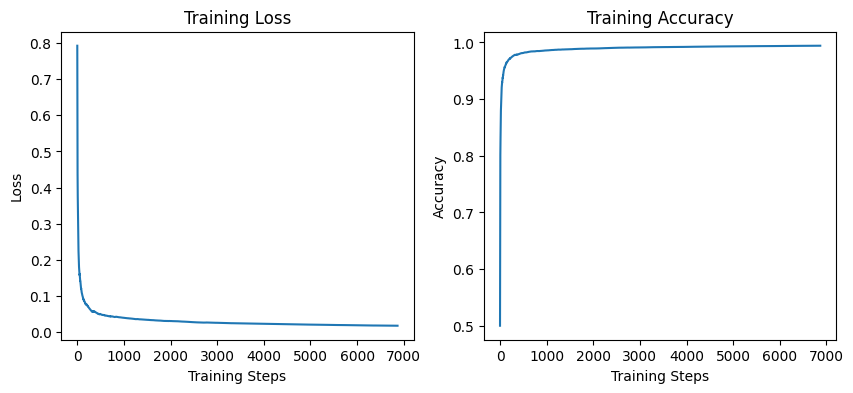

In [7]:
# Training hyperparameters
params = dict(
  batch_size = 32,
  num_epochs = 2,
  learning_rate = 5e-4,
)

# TODO 2: Define optimizer using Adam
optimizer = tf.keras.optimizers.Adam(learning_rate=params["learning_rate"])

# TODO 3: Compile the model
standard_classifier.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

#Train the model using batches from the dataset loader

loss_history = []
acc_history = []

for epoch in range(params["num_epochs"]):

    for step in range(loader.get_train_size() // params["batch_size"]):

        images, labels = loader.get_batch(params["batch_size"])

        # TODO 4: train the model using train_on_batch
        loss, acc = standard_classifier.train_on_batch(images, labels)

        # TODO 5: store loss and accuracy values in loss_history and acc_history
        loss_history.append(loss)
        acc_history.append(acc)

# Visualize the training performance
# Plot loss and accuracy curves using matplotlib

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")

plt.subplot(1,2,2)
plt.plot(acc_history)
plt.title("Training Accuracy")
plt.xlabel("Training Steps")
plt.ylabel("Accuracy")

plt.show()

### Evaluate performance of the standard CNN

Next, let's evaluate the classification performance of our CelebA-trained standard CNN on the training dataset.


In [8]:
### Evaluate the CNN classifier ###

# Define a batch size for evaluation to reduce RAM usage
eval_batch_size = 64 # You can adjust this value based on your system's RAM and dataset size

all_predictions = []
all_labels_eval = []

# Iterate through the dataset in batches for evaluation
num_evaluation_steps = loader.get_train_size() // eval_batch_size
if loader.get_train_size() % eval_batch_size != 0:
    num_evaluation_steps += 1 # Account for any remaining samples

for _ in range(num_evaluation_steps):
    # TODO 6: Load a batch of images and labels from the dataset
    images_batch, labels_batch = loader.get_batch(eval_batch_size)

    # TODO 7: Use the trained CNN model to generate predictions for the images in the batch
    logits_batch = standard_classifier.predict(images_batch)

    # TODO 8: Convert the logits to probabilities using the sigmoid function
    probs_batch = tf.sigmoid(logits_batch)

    # TODO 9: Convert probabilities into binary predictions (0 or 1)
    predictions_batch = tf.round(probs_batch)

    all_predictions.append(predictions_batch)
    all_labels_eval.append(labels_batch)

# Concatenate all batch predictions and labels
predictions = tf.concat(all_predictions, axis=0)
labels_eval = tf.concat(all_labels_eval, axis=0)

# TODO 10: Compute the classification accuracy
acc_standard = tf.reduce_mean(tf.cast(tf.equal(predictions, labels_eval), tf.float32))

# Print the final accuracy
print("Standard CNN accuracy on training set: {:.4f}".format(acc_standard.numpy()))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━

We will also evaluate our networks on an independent test dataset containing faces that were not seen during training. For the test data, we'll look at the classification accuracy across four different demographics, based on the Fitzpatrick skin scale and sex-based labels: dark-skinned male, dark-skinned female, light-skinned male, and light-skinned female.

Let's take a look at some sample faces in the test set.

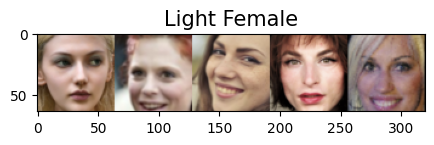

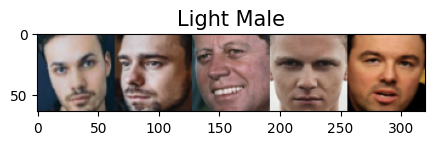

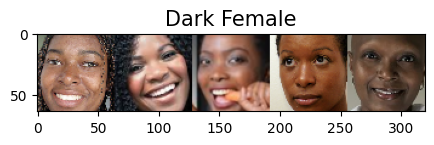

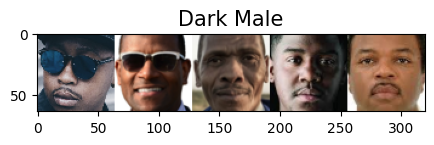

In [9]:
### Load test dataset and plot examples ###

test_faces = mdl.lab2.get_test_faces()
keys = ["Light Female", "Light Male", "Dark Female", "Dark Male"]
for group, key in zip(test_faces,keys):
  plt.figure(figsize=(5,5))
  plt.imshow(np.hstack(group))
  plt.title(key, fontsize=15)

Now, let's evaluate the probability of each of these face demographics being classified as a face using the standard CNN classifier we've just trained.

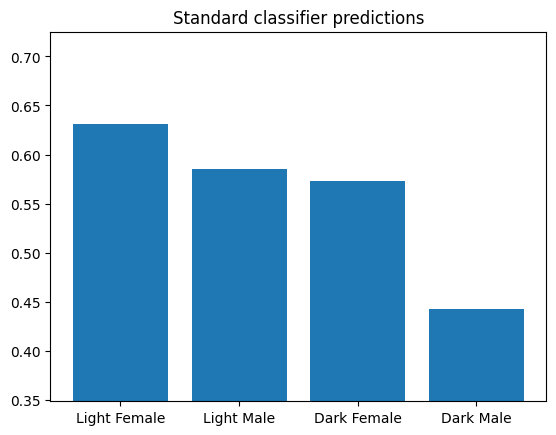

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
### Evaluate the standard CNN on the test data ###

standard_classifier_logits = [standard_classifier(np.array(x, dtype=np.float32)) for x in test_faces]
standard_classifier_probs = tf.squeeze(tf.sigmoid(standard_classifier_logits))

# Plot the prediction accuracies per demographic
xx = range(len(keys))
yy = standard_classifier_probs.numpy().mean(1)
plt.bar(xx, yy)
plt.xticks(xx, keys)
plt.ylim(max(0,yy.min()-np.ptp(yy)/2.), yy.max()+np.ptp(yy)/2.)
plt.title("Standard classifier predictions");

Take a look at the accuracies for this first model across these four groups. What do you observe? Would you consider this model biased or unbiased? What are some reasons why a trained model may have biased accuracies?

The data is biased towards the Light Female and Male as compared to the Dark Female and Male. This shows biasedness in the trained data.
One of the reason for biased accuracies in trained model might be due imbalanced training datasets that overrepresent light-skinned as compared to dark-skinned or even due to technical difficulties with the lighting on the features.

Disclaimer: Due to crashing of the RAM, we have reduced the data.